In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import keras_tuner as kt
import random

print("Cell 1/10: Libraries imported.")

seed_value = 42 # You can use any integer
tf.random.set_seed(seed_value)
np.random.seed(seed_value)
random.seed(seed_value)

Cell 1/10: Libraries imported.


In [33]:
# --- This cell is configured for Standard BERT ---
filename = 'BTC_with_Standard_BERT_sentiment.csv'
sentiment_column_name = 'sentiment_score_std_bert' # The column name from the Standard BERT script
# -----------------------------------------------

# Load the data
try:
    df = pd.read_csv(filename)
except FileNotFoundError:
    print(f"--- FILE NOT FOUND ---")
    print(f"Error: The file '{filename}' was not found. Please make sure it's available.")
    exit()

# Select the features we will use for prediction
features = ['close_price', sentiment_column_name]
df = df.dropna(subset=features)
dataset = df[features].values

# Scale the data to be between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_dataset = scaler.fit_transform(dataset)

print("Cell 2/9: Standard BERT dataset loaded and scaled.")

Cell 2/9: Standard BERT dataset loaded and scaled.


In [34]:
def create_sequences(dataset, look_back=60):
    """
    Transforms a time series dataset into input sequences (X) and their corresponding output values (y).
    """
    X, y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), :])
        y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(y)

# Split into training (80%) and testing (20%) sets
train_size = int(len(scaled_dataset) * 0.8)
train_data, test_data = scaled_dataset[0:train_size, :], scaled_dataset[train_size:len(scaled_dataset), :]

# Define the lookback period
look_back = 60

# Create the sequences for training and testing
X_train, y_train = create_sequences(train_data, look_back)
X_test, y_test = create_sequences(test_data, look_back)

print(f"Cell 3/9: Training and testing sequences created.")
print(f"Shape of X_train: {X_train.shape}")

Cell 3/9: Training and testing sequences created.
Shape of X_train: (1400, 60, 2)


In [35]:
def build_model(hp):
    """
    This function builds the LSTM model and defines the hyperparameter search space.
    """
    model = Sequential()

    # --- Define Hyperparameter Search Space ---
    # We'll tune the number of units in the LSTM layers.
    hp_units = hp.Int('units', min_value=32, max_value=128, step=16)
    
    # We'll tune the dropout rate.
    hp_dropout = hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1)
    
    # We'll tune the learning rate for the optimizer.
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    # -----------------------------------------

    # Build the model using the hyperparameters
    model.add(LSTM(units=hp_units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(rate=hp_dropout))
    model.add(LSTM(units=hp_units, return_sequences=False))
    model.add(Dropout(rate=hp_dropout))
    model.add(Dense(units=1))

    # Compile the model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
        loss='mean_squared_error'
    )
    
    return model

print("Cell : Hyperparameter model builder function created.")

Cell : Hyperparameter model builder function created.


In [36]:
# Instantiate the tuner.
# Hyperband is an efficient algorithm for hyperparameter optimization.
tuner = kt.Hyperband(
    build_model,
    objective='val_loss', # The metric to minimize (validation loss)
    max_epochs=50,
    factor=3,
    directory='lstm_tuner',
    project_name='btc_sentiment'
)

# Create a callback to stop training early if the validation loss stops improving
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

print("Starting hyperparameter search... (This will take a significant amount of time)")
tuner.search(
    X_train,
    y_train,
    epochs=50,
    validation_data=(X_test, y_test),
    callbacks=[stop_early]
)

print("\nCell 6/10: Hyperparameter search complete.")

Reloading Tuner from lstm_tuner/btc_sentiment/tuner0.json
Starting hyperparameter search... (This will take a significant amount of time)

Cell 6/10: Hyperparameter search complete.


In [37]:
# Get the optimal hyperparameters from the tuner
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
The hyperparameter search is complete. 
The optimal number of units in the LSTM layers is {best_hps.get('units')}.
The optimal dropout rate is {best_hps.get('dropout')}.
The optimal learning rate for the optimizer is {best_hps.get('learning_rate')}.
""")

print("\nCell 7/11: Best hyperparameters retrieved.")


The hyperparameter search is complete. 
The optimal number of units in the LSTM layers is 128.
The optimal dropout rate is 0.2.
The optimal learning rate for the optimizer is 0.01.


Cell 7/11: Best hyperparameters retrieved.


In [38]:
# Build the model with the optimal hyperparameters
final_model = tuner.hypermodel.build(best_hps)

print("Retraining the best model on the full training data... (This will take some time)")

# Retrain the model
history = final_model.fit(
    X_train,
    y_train,
    epochs=50, # Train for the full number of epochs
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)] # Use a slightly more patient early stopping
)

print("\nCell 8/11: Final model training complete.")

Retraining the best model on the full training data... (This will take some time)
Epoch 1/50


/Users/hamza/Desktop/Thesis/thesis_env/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0888 - val_loss: 0.0012
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0028 - val_loss: 7.2733e-04
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0022 - val_loss: 6.6485e-04
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0017 - val_loss: 9.2232e-04
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.0016 - val_loss: 4.9090e-04
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0019 - val_loss: 0.0012
Epoch 7/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0016 - val_loss: 0.0016
Epoch 8/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0018 - val_loss: 4.7880e-04
Epoch 9/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0018 - val_loss: 0.0015
Epoch 10/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0017 - val_loss: 3.7548e-04
Epoch 11/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0017 - val_loss: 9.9715e-04
Epoch 12/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms

In [39]:
# Make predictions on the test set using the final, retrained model
predictions_scaled = final_model.predict(X_test)

# Inverse the scaling to get actual price values
dummy_array = np.zeros((len(predictions_scaled), X_train.shape[2]))
dummy_array[:, 0] = predictions_scaled.flatten()
predictions = scaler.inverse_transform(dummy_array)[:, 0]

# Inverse scale the true values for comparison
dummy_array_y_test = np.zeros((len(y_test), X_train.shape[2]))
dummy_array_y_test[:, 0] = y_test.flatten()
y_test_actual = scaler.inverse_transform(dummy_array_y_test)[:, 0]

print("Cell 9/11: Predictions made with the final optimal model.")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Cell 9/11: Predictions made with the final optimal model.


In [40]:
# --- Quantitative Metrics ---
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
mae = mean_absolute_error(y_test_actual, predictions)

# --- Directional Accuracy ---
results_df = pd.DataFrame({'true_price': y_test_actual, 'predicted_price': predictions})
results_df['true_direction'] = np.sign(results_df['true_price'].diff())
results_df['predicted_direction'] = np.sign(results_df['predicted_price'].diff())
correct_predictions = (results_df['true_direction'] * results_df['predicted_direction'] >= 0).sum()
directional_accuracy = correct_predictions / len(results_df.dropna())

print("\n--- Final Optimized Model Evaluation (Standard BERT) ---")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Directional Accuracy: {directional_accuracy:.2%}")
print("\nCell 10/11: Performance metrics calculated.")


--- Final Optimized Model Evaluation (Standard BERT) ---
Root Mean Squared Error (RMSE): $1066.29
Mean Absolute Error (MAE): $787.05
Directional Accuracy: 49.51%

Cell 10/11: Performance metrics calculated.


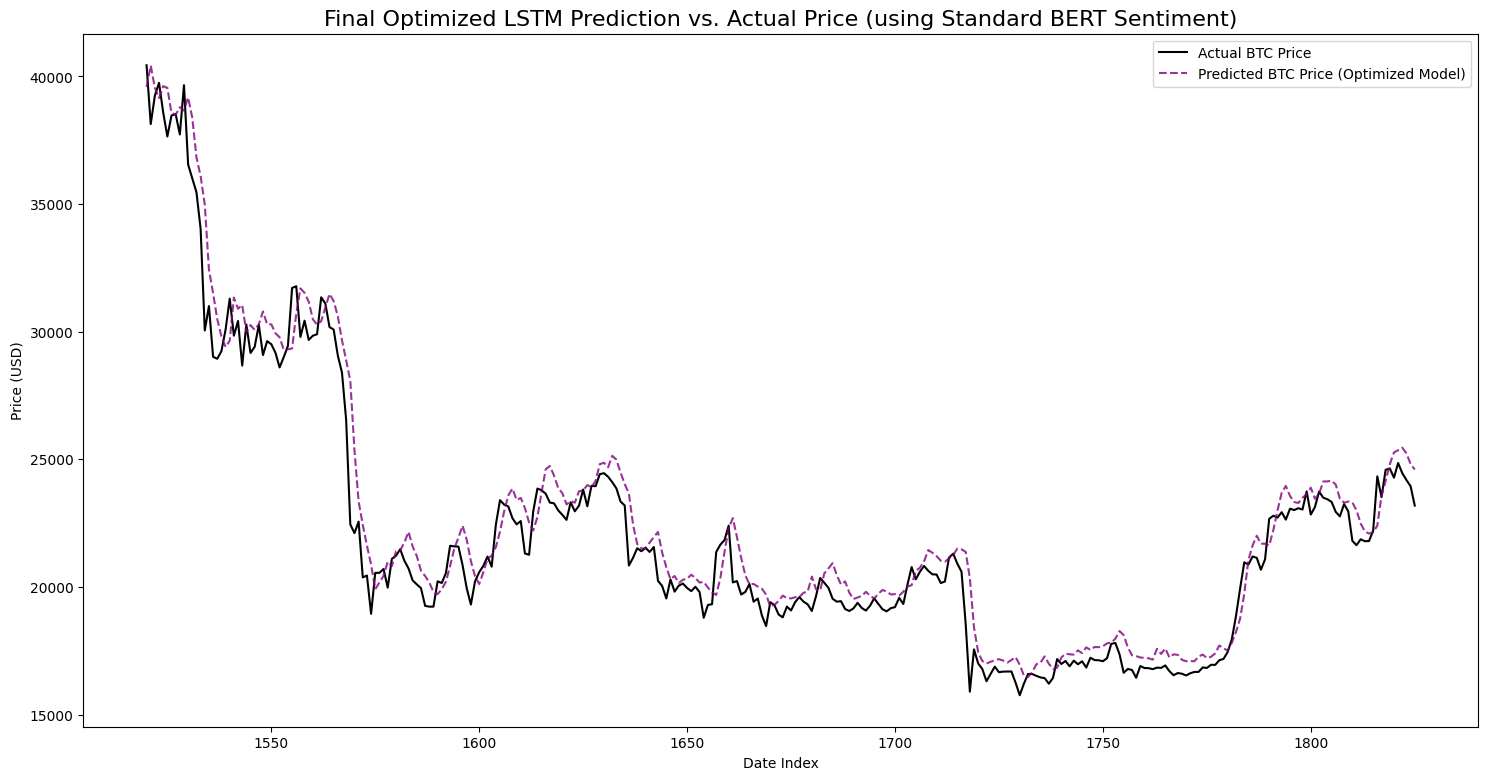


Cell 11/11: Visualization generated. Analysis finished.


In [41]:
# Find the correct index for plotting
test_start_index = len(df) - len(predictions)
plot_index = df.index[test_start_index:]

plt.figure(figsize=(18, 9))
plt.plot(plot_index, y_test_actual, color='black', label='Actual BTC Price')
plt.plot(plot_index, predictions, color='purple', linestyle='--', alpha=0.8, label='Predicted BTC Price (Optimized Model)')
plt.title('Final Optimized LSTM Prediction vs. Actual Price (using Standard BERT Sentiment)', fontsize=16)
plt.xlabel('Date Index')
plt.ylabel('Price (USD)')
plt.legend()
plt.savefig('lstm_tuned_prediction_standard_bert.png')
plt.show()

print("\nCell 11/11: Visualization generated. Analysis finished.")

In [42]:
# --- This is the new, upgraded evaluation cell ---

# --- Quantitative Metrics (RMSE & MAE) ---
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
mae = mean_absolute_error(y_test_actual, predictions)

# --- Create a DataFrame for Directional Accuracy Analysis ---
# We need to align the true prices with the predictions.
# The first prediction corresponds to the price at index `train_size + look_back`.
results_df = pd.DataFrame({
    'true_price': y_test_actual.flatten(),
    'predicted_price': predictions.flatten()
}, index=df.index[train_size + look_back : train_size + look_back + len(y_test_actual)])


# --- 1. Short-Term (1-Day) Directional Accuracy ---
# This is the original method.
# It checks if the model correctly predicted if the next day's price would be up or down compared to the day before.
results_df['true_direction_1d'] = np.sign(results_df['true_price'].diff())
results_df['predicted_direction_1d'] = np.sign(results_df['predicted_price'].diff())
correct_predictions_1d = (results_df['true_direction_1d'] * results_df['predicted_direction_1d'] >= 0).sum()
directional_accuracy_1d = correct_predictions_1d / len(results_df.dropna())


# --- 2. Long-Term (7-Day) Directional Accuracy ---
# Here, we check if the model's prediction for TOMORROW can predict the trend for the NEXT 7 DAYS.
# The predicted direction is simply whether the model thinks tomorrow's price is higher than today's.
results_df['predicted_direction_longterm'] = np.sign(results_df['predicted_price'] - results_df['true_price'].shift(1))

# The actual long-term direction is whether the price in 7 days is higher than today's price.
results_df['true_direction_7d'] = np.sign(results_df['true_price'].shift(-6) - results_df['true_price'])
correct_predictions_7d = (results_df['predicted_direction_longterm'] * results_df['true_direction_7d'] >= 0).sum()
directional_accuracy_7d = correct_predictions_7d / len(results_df.dropna())


# --- 3. Long-Term (30-Day) Directional Accuracy ---
# Same logic, but for a 30-day horizon.
results_df['true_direction_30d'] = np.sign(results_df['true_price'].shift(-29) - results_df['true_price'])
correct_predictions_30d = (results_df['predicted_direction_longterm'] * results_df['true_direction_30d'] >= 0).sum()
directional_accuracy_30d = correct_predictions_30d / len(results_df.dropna())


# --- Print All Results ---
print("\n--- Final Optimized Baseline Model Evaluation ---")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print("---------------------------------------------")
print(f"Directional Accuracy (1-Day Horizon): {directional_accuracy_1d:.2%}")
print(f"Directional Accuracy (7-Day Horizon): {directional_accuracy_7d:.2%}")
print(f"Directional Accuracy (30-Day Horizon): {directional_accuracy_30d:.2%}")
print("\nCell 10/11: Performance metrics calculated.")


--- Final Optimized Baseline Model Evaluation ---
Root Mean Squared Error (RMSE): $1066.29
Mean Absolute Error (MAE): $787.05
---------------------------------------------
Directional Accuracy (1-Day Horizon): 49.51%
Directional Accuracy (7-Day Horizon): 53.18%
Directional Accuracy (30-Day Horizon): 50.00%

Cell 10/11: Performance metrics calculated.


In [43]:
model_name = 'LSTM_Bert' 

In [44]:

# ## 12. Save Final Predictions to a File
# This cell takes the final 'true_price' and 'predicted_price' and saves them
# to a CSV file. This allows for easy comparison with other models later.

# Create a dataframe from the results
# The index will be the date, which is important for alignment later
predictions_df = pd.DataFrame({
    'true_price': y_test_actual.flatten(),
    'predicted_price': predictions.flatten()
}, index=plot_index)

# Define the output filename using the model_name from Cell 2
output_filename = f'predictions_{model_name}.csv'

# Save to CSV
predictions_df.to_csv(output_filename)

print(f"\nCell 12/12: Predictions saved successfully to '{output_filename}'")


Cell 12/12: Predictions saved successfully to 'predictions_LSTM_Bert.csv'


In [45]:
# --- Advanced Analysis: Volatility Regime Performance (Corrected) ---
# This cell assumes you have already run the model and have the following variables in memory:
# - df: The original dataframe with the full history
# - y_test_actual: The true prices for the test set
# - predictions: The model's predicted prices for the test set

try:
    # 1. Create a results dataframe with the correct date index
    # Get the actual dates for the test set predictions
    test_dates = df['date'].iloc[len(df) - len(predictions):]
    results_df = pd.DataFrame({
        'true_price': y_test_actual.flatten(),
        'predicted_price': predictions.flatten()
    }, index=pd.to_datetime(test_dates))


    # 2. Calculate daily returns and rolling volatility on the original full dataframe
    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date')
    df['daily_return'] = df['close_price'].pct_change()
    df['volatility'] = df['daily_return'].rolling(window=30).std()


    # 3. Join the volatility data with the results dataframe
    # The join now works correctly because both dataframes share a datetime index
    regime_df = results_df.join(df['volatility']).dropna()


    # 4. Define the volatility regimes using quantiles (dividing data into three equal parts)
    low_vol_threshold = regime_df['volatility'].quantile(0.33)
    high_vol_threshold = regime_df['volatility'].quantile(0.66)

    def assign_regime(volatility):
        if volatility <= low_vol_threshold:
            return 'Low Volatility'
        elif volatility <= high_vol_threshold:
            return 'Normal Volatility'
        else:
            return 'High Volatility'

    regime_df['regime'] = regime_df['volatility'].apply(assign_regime)


    # 5. Calculate performance metrics for each regime
    print("\n--- Performance by Market Regime ---")

    for regime, group_df in regime_df.groupby('regime'):
        # Ensure the group is not empty
        if len(group_df) < 2:
            print(f"\nSkipping {regime}: Not enough data points.")
            continue

        rmse = np.sqrt(mean_squared_error(group_df['true_price'], group_df['predicted_price']))
        
        # Calculate directional accuracy for the subset
        group_df['true_direction'] = np.sign(group_df['true_price'].diff())
        group_df['predicted_direction'] = np.sign(group_df['predicted_price'].diff())
        
        # Calculate correct predictions, handling potential NaNs from diff()
        correct_predictions = (group_df['true_direction'] * group_df['predicted_direction'] >= 0).sum()
        directional_accuracy = correct_predictions / len(group_df.dropna(subset=['true_direction', 'predicted_direction']))
        
        print(f"\nResults for {regime} ({len(group_df)} days):")
        print(f"  - RMSE: ${rmse:.2f}")
        print(f"  - Directional Accuracy: {directional_accuracy:.2%}")

except NameError:
    print("Error: Please make sure you have run the full LSTM training and prediction script first.")
except Exception as e:
    print(f"An error occurred: {e}")


--- Performance by Market Regime ---

Results for High Volatility (104 days):
  - RMSE: $1354.19
  - Directional Accuracy: 43.69%

Results for Low Volatility (101 days):
  - RMSE: $742.64
  - Directional Accuracy: 52.00%

Results for Normal Volatility (101 days):
  - RMSE: $1002.44
  - Directional Accuracy: 56.00%


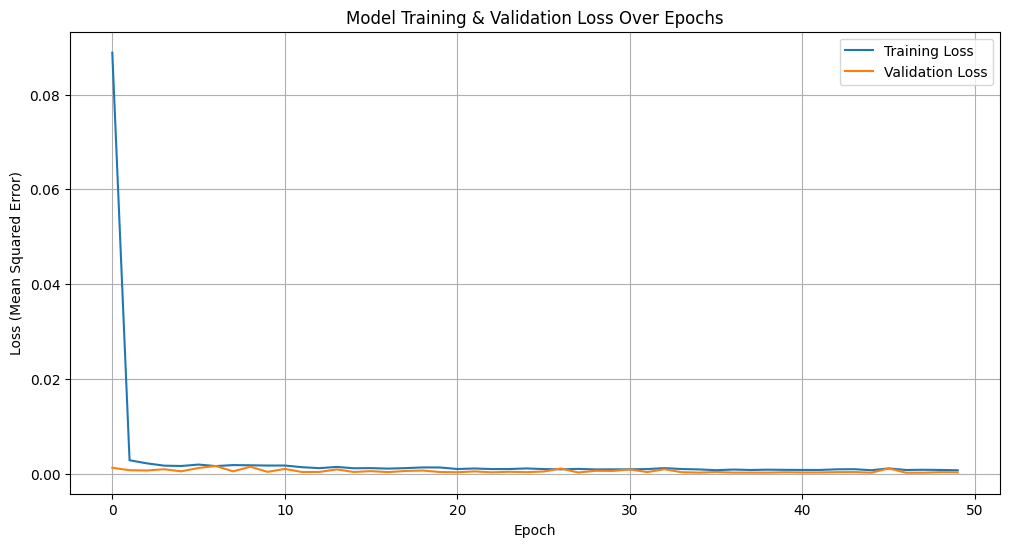

In [46]:
# --- ADD THIS CELL TO PLOT TRAINING & VALIDATION LOSS ---

# Create a plot for the training and validation loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Training & Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.savefig('lstm_tuned_loss_curve_baseline.png')
plt.show()